<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/notebooks/11_cross_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
import numpy as np
from scipy.sparse import load_npz

uploaded = files.upload()  # Upload 4 files:
                           # X_train.npz, y_train.npy
                           # sa_X_train.npz, sa_y_train.npy

# Load UCI training data
X_uci = load_npz('X_train.npz')
y_uci = np.load('y_train.npy', allow_pickle=True)

# Load SpamAssassin training data
X_sa = load_npz('sa_X_train.npz')
y_sa = np.load('sa_y_train.npy', allow_pickle=True)

print("UCI training shape:", X_uci.shape)
print("SpamAssassin training shape:", X_sa.shape)

Saving sa_y_train.npy to sa_y_train (1).npy
Saving sa_X_train.npz to sa_X_train (1).npz
Saving y_train.npy to y_train (1).npy
Saving X_train.npz to X_train (1).npz
UCI training shape: (4135, 5000)
SpamAssassin training shape: (4263, 5000)


In [5]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded!")

Libraries loaded!


In [6]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Models and CV strategy defined!")
print("Strategy: 5-Fold Stratified Cross Validation")

Models and CV strategy defined!
Strategy: 5-Fold Stratified Cross Validation


In [7]:
print("=== 5-Fold Cross Validation — UCI SMS Dataset ===\n")

uci_cv_results = {}

for name, model in models.items():
    print(f"Running CV for {name}...")
    scores = cross_val_score(model, X_uci, y_uci,
                            cv=cv, scoring='f1_macro')
    uci_cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores.tolist()
    }
    print(f"  F1 per fold: {[round(s,4) for s in scores]}")
    print(f"  Mean F1:     {scores.mean():.4f}")
    print(f"  Std Dev:     {scores.std():.4f}\n")

=== 5-Fold Cross Validation — UCI SMS Dataset ===

Running CV for Naive Bayes...
  F1 per fold: [np.float64(0.8832), np.float64(0.9056), np.float64(0.9232), np.float64(0.8844), np.float64(0.8568)]
  Mean F1:     0.8906
  Std Dev:     0.0225

Running CV for Logistic Regression...
  F1 per fold: [np.float64(0.8568), np.float64(0.8663), np.float64(0.8993), np.float64(0.8715), np.float64(0.7994)]
  Mean F1:     0.8587
  Std Dev:     0.0328

Running CV for SVM...
  F1 per fold: [np.float64(0.9273), np.float64(0.9497), np.float64(0.9568), np.float64(0.9474), np.float64(0.9227)]
  Mean F1:     0.9408
  Std Dev:     0.0133

Running CV for Random Forest...
  F1 per fold: [np.float64(0.9092), np.float64(0.9334), np.float64(0.9334), np.float64(0.9213), np.float64(0.878)]
  Mean F1:     0.9150
  Std Dev:     0.0206



In [8]:
print("=== 5-Fold Cross Validation — SpamAssassin Dataset ===\n")

sa_cv_results = {}

for name, model in models.items():
    print(f"Running CV for {name}...")
    scores = cross_val_score(model, X_sa, y_sa,
                            cv=cv, scoring='f1_macro')
    sa_cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores.tolist()
    }
    print(f"  F1 per fold: {[round(s,4) for s in scores]}")
    print(f"  Mean F1:     {scores.mean():.4f}")
    print(f"  Std Dev:     {scores.std():.4f}\n")

=== 5-Fold Cross Validation — SpamAssassin Dataset ===

Running CV for Naive Bayes...
  F1 per fold: [np.float64(0.9836), np.float64(0.9614), np.float64(0.9878), np.float64(0.9795), np.float64(0.9711)]
  Mean F1:     0.9767
  Std Dev:     0.0094

Running CV for Logistic Regression...
  F1 per fold: [np.float64(0.9808), np.float64(0.9671), np.float64(0.9891), np.float64(0.9822), np.float64(0.9737)]
  Mean F1:     0.9786
  Std Dev:     0.0075

Running CV for SVM...
  F1 per fold: [np.float64(0.9919), np.float64(0.9865), np.float64(0.9932), np.float64(0.9919), np.float64(0.9918)]
  Mean F1:     0.9910
  Std Dev:     0.0024

Running CV for Random Forest...
  F1 per fold: [np.float64(0.9905), np.float64(0.974), np.float64(0.9864), np.float64(0.9891), np.float64(0.9795)]
  Mean F1:     0.9839
  Std Dev:     0.0063



In [9]:
print("=== Cross Validation Summary ===\n")
print(f"{'Model':<25} {'UCI Mean F1':<15} {'UCI Std':<12} {'SA Mean F1':<15} {'SA Std':<12}")
print("-" * 80)

for name in models.keys():
    uci_mean = uci_cv_results[name]['mean']
    uci_std = uci_cv_results[name]['std']
    sa_mean = sa_cv_results[name]['mean']
    sa_std = sa_cv_results[name]['std']
    print(f"{name:<25} {uci_mean:.4f}{'':>5} {uci_std:.4f}{'':>5} {sa_mean:.4f}{'':>5} {sa_std:.4f}")

print("\nNote: Lower Std Dev = More stable and reliable model")

=== Cross Validation Summary ===

Model                     UCI Mean F1     UCI Std      SA Mean F1      SA Std      
--------------------------------------------------------------------------------
Naive Bayes               0.8906      0.0225      0.9767      0.0094
Logistic Regression       0.8587      0.0328      0.9786      0.0075
SVM                       0.9408      0.0133      0.9910      0.0024
Random Forest             0.9150      0.0206      0.9839      0.0063

Note: Lower Std Dev = More stable and reliable model


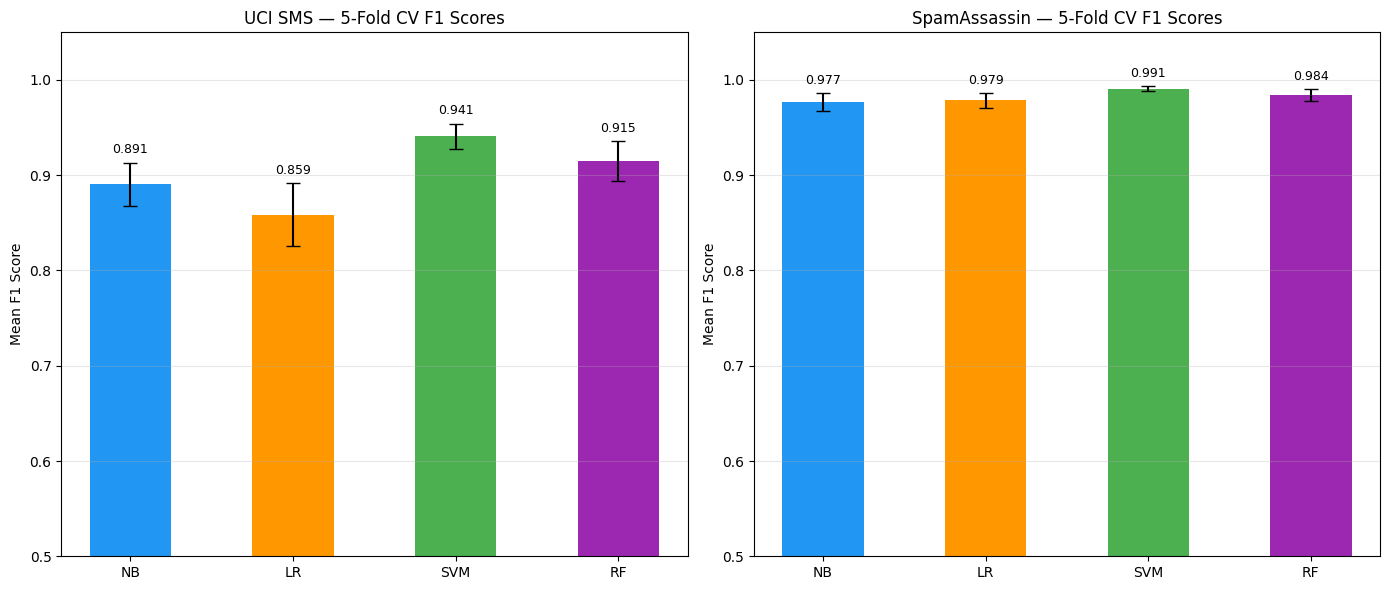

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_names = list(models.keys())
short_names = ['NB', 'LR', 'SVM', 'RF']
x = np.arange(len(model_names))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

# UCI plot
uci_means = [uci_cv_results[m]['mean'] for m in model_names]
uci_stds = [uci_cv_results[m]['std'] for m in model_names]
axes[0].bar(x, uci_means, 0.5, yerr=uci_stds,
            capsize=5, color=colors)
axes[0].set_title('UCI SMS — 5-Fold CV F1 Scores')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_ylabel('Mean F1 Score')
axes[0].grid(axis='y', alpha=0.3)
for i, (mean, std) in enumerate(zip(uci_means, uci_stds)):
    axes[0].text(i, mean + std + 0.01, f'{mean:.3f}',
                ha='center', fontsize=9)

# SpamAssassin plot
sa_means = [sa_cv_results[m]['mean'] for m in model_names]
sa_stds = [sa_cv_results[m]['std'] for m in model_names]
axes[1].bar(x, sa_means, 0.5, yerr=sa_stds,
            capsize=5, color=colors)
axes[1].set_title('SpamAssassin — 5-Fold CV F1 Scores')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_ylabel('Mean F1 Score')
axes[1].grid(axis='y', alpha=0.3)
for i, (mean, std) in enumerate(zip(sa_means, sa_stds)):
    axes[1].text(i, mean + std + 0.01, f'{mean:.3f}',
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('cv_comparison.png')
plt.show()

In [12]:
import json

cv_results = {
    'UCI': uci_cv_results,
    'SpamAssassin': sa_cv_results
}

with open('cv_results.json', 'w') as f:
    json.dump(cv_results, f)

print("Cross validation results saved!")

Cross validation results saved!
